# Stage 2: Data Collection & Data Understanding

---

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## 2.1 Load Dataset

**Dataset:** Water Potability from Kaggle  
**Download link:** https://www.kaggle.com/datasets/adityakadiwal/water-potability  
Place the CSV at: `data/raw/water_potability.csv`

In [18]:
df = pd.read_csv('./data/raw/water_potability.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded: 3276 rows × 10 columns


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


## 2.2 Dataset Overview

In [19]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== BASIC INFO ===')
df.info()

=== SHAPE ===
Rows: 3276, Columns: 10

=== DATA TYPES ===
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

=== BASIC INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null 

In [20]:
print('=== STATISTICAL SUMMARY ===')
df.describe().T.round(3)

=== STATISTICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.081,1.594,0.000,6.093,7.037,8.062,14.000
Hardness,3276.0,196.369,32.880,47.432,176.851,196.968,216.667,323.124
Solids,3276.0,22014.093,8768.571,320.943,15666.690,20927.834,27332.762,61227.196
Chloramines,3276.0,7.122,1.583,0.352,6.127,7.130,8.115,13.127
Sulfate,2495.0,333.776,41.417,129.000,307.699,333.074,359.950,481.031
Conductivity,3276.0,426.205,80.824,181.484,365.734,421.885,481.792,753.343
Organic_carbon,3276.0,14.285,3.308,2.200,12.066,14.218,16.558,28.300
Trihalomethanes,3114.0,66.396,16.175,0.738,55.845,66.622,77.337,124.000
Turbidity,3276.0,3.967,0.780,1.450,3.440,3.955,4.500,6.739
Potability,3276.0,0.390,0.488,0.000,0.000,0.000,1.000,1.000


## 2.3 Target Class Distribution

=== TARGET DISTRIBUTION ===
  Non-Potable (Unsafe): 1998 samples (61.0%)
  Potable (Safe): 1278 samples (39.0%)


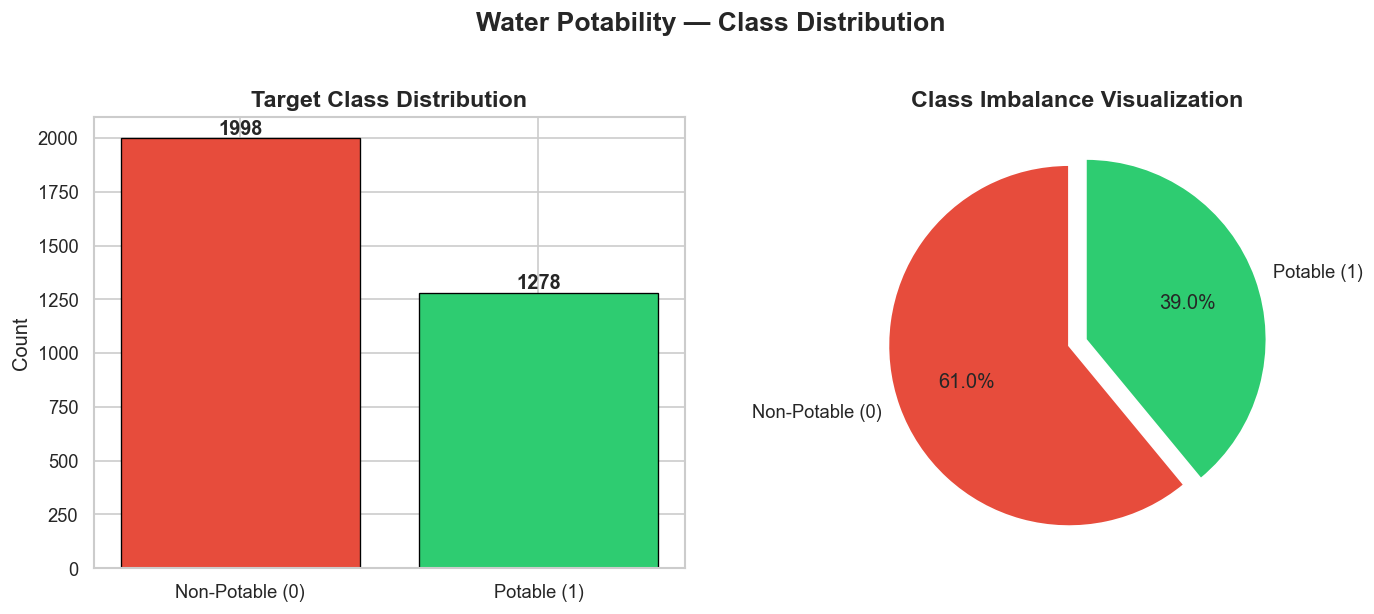


⚠️  Class imbalance detected! Will apply SMOTE in Stage 6.


In [21]:
# Class counts
class_counts = df['Potability'].value_counts()
class_pct = df['Potability'].value_counts(normalize=True) * 100

print('=== TARGET DISTRIBUTION ===')
for cls, cnt in class_counts.items():
    label = 'Potable (Safe)' if cls == 1 else 'Non-Potable (Unsafe)'
    print(f'  {label}: {cnt} samples ({class_pct[cls]:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Non-Potable (0)', 'Potable (1)'], class_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Potable (0)', 'Potable (1)'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Imbalance Visualization', fontsize=14, fontweight='bold')

plt.suptitle('Water Potability — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./data/processed/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n⚠️  Class imbalance detected! Will apply SMOTE in Stage 6.')

## 2.4 Missing Values Analysis

=== MISSING VALUES ===
                 Missing Count  Missing %
ph                         491      14.99
Sulfate                    781      23.84
Trihalomethanes            162       4.95


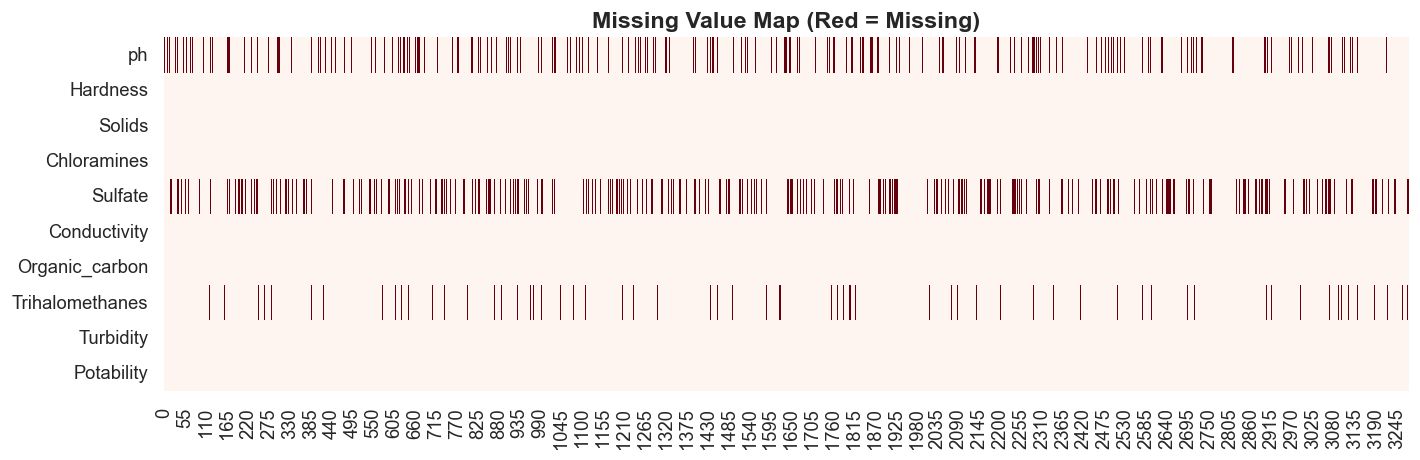


Observation: pH, Sulfate, and Trihalomethanes have significant missing values.
Strategy: Median imputation per class (handled in Stage 3).


In [22]:
# Missing value counts
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== MISSING VALUES ===')
print(missing_df)

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', yticklabels=True)
plt.title('Missing Value Map (Red = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/missing_values_map.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nObservation: pH, Sulfate, and Trihalomethanes have significant missing values.')
print('Strategy: Median imputation per class (handled in Stage 3).')

## 2.5 Feature Descriptions with WHO Benchmarks

In [23]:
who_limits = {
    'ph': ('6.5 – 8.5', 'Neutral to slightly alkaline'),
    'Hardness': ('< 300 mg/L', 'Calcium/Magnesium salts'),
    'Solids': ('< 500 ppm', 'Total Dissolved Solids'),
    'Chloramines': ('< 4 ppm', 'Disinfectant used in water treatment'),
    'Sulfate': ('< 250 mg/L', 'Naturally occurring mineral'),
    'Conductivity': ('< 400 μS/cm', 'Ion content indicator'),
    'Organic_carbon': ('< 2 ppm', 'Organic compound indicator'),
    'Trihalomethanes': ('< 80 μg/L', 'Disinfection byproduct'),
    'Turbidity': ('< 5 NTU', 'Water clarity')
}

print(f'{"Feature":<20} {"WHO Safe Limit":<20} {"Description"}')
print('─' * 75)
for feat, (limit, desc) in who_limits.items():
    print(f'{feat:<20} {limit:<20} {desc}')

Feature              WHO Safe Limit       Description
───────────────────────────────────────────────────────────────────────────
ph                   6.5 – 8.5            Neutral to slightly alkaline
Hardness             < 300 mg/L           Calcium/Magnesium salts
Solids               < 500 ppm            Total Dissolved Solids
Chloramines          < 4 ppm              Disinfectant used in water treatment
Sulfate              < 250 mg/L           Naturally occurring mineral
Conductivity         < 400 μS/cm          Ion content indicator
Organic_carbon       < 2 ppm              Organic compound indicator
Trihalomethanes      < 80 μg/L            Disinfection byproduct
Turbidity            < 5 NTU              Water clarity


In [24]:
# Save raw copy for reference
df.to_csv('./data/processed/water_potability_raw_copy.csv', index=False)
print('Raw data copy saved to data/processed/ ✓')

Raw data copy saved to data/processed/ ✓
